Import Library & Setup Environment

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup token API untuk integrasi data di masa mendatang
os.environ['LIGA1_API_TOKEN'] = "KGAT_03727d85bf77314d562ee16d7b07a77f"

# Machine Learning & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

DATA COLLECTION & PEMBUATAN DATASET

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Joyzz1945/persijadata/refs/heads/main/stat.csv")

In [3]:
df

,Unnamed: 0,club,conversion rate,shot/match
0,1,Bhayangkara S.,11,12.42
1,2,Persib,11,12.85
2,3,Arema,12,10.62
3,4,Persebaya S.,15,10.74
4,5,Bali Utd,12,13.47
5,6,PSIS Semarang,10,10.82
6,7,Borneo,13,9.82
7,8,Persija,12,10.65
8,9,Persita,10,11.18
9,10,Madura Utd,12,10.72


Exploratory Data Analysis (EDA)

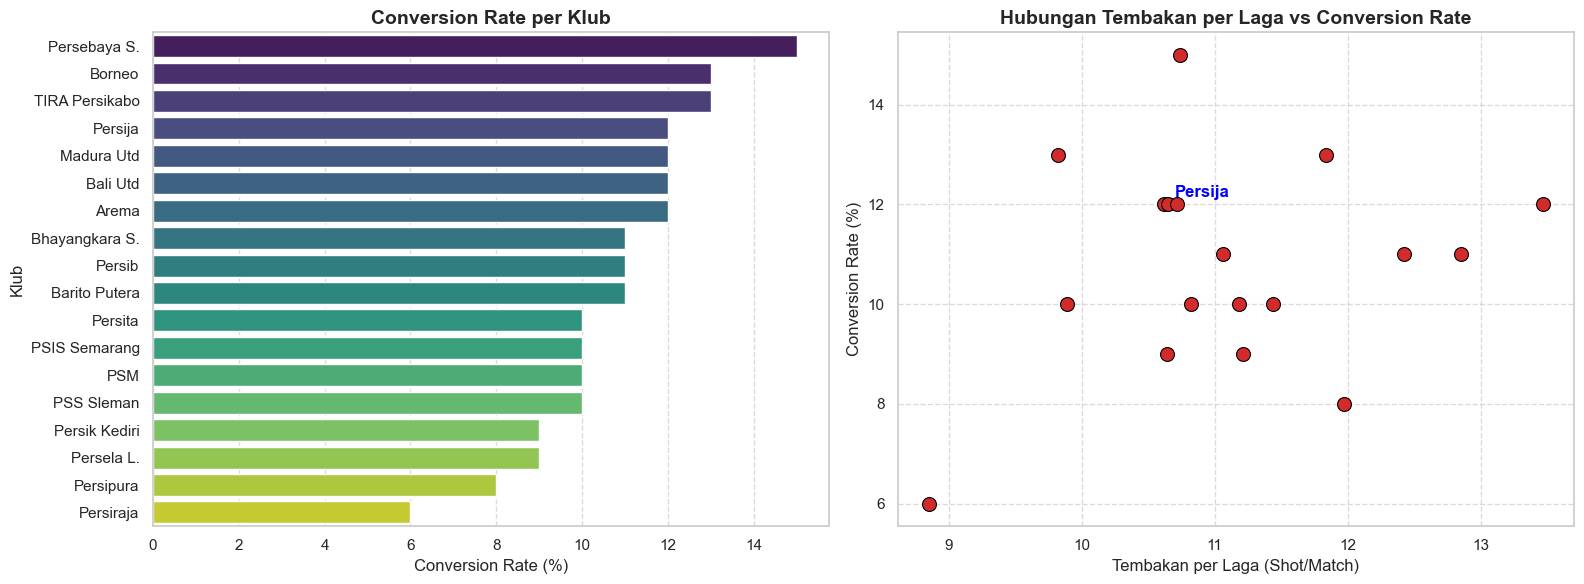

Korelasi antara Tembakan per Laga dan Conversion Rate:


,Conversion_Rate_Pct,Shot_per_Match
Conversion_Rate_Pct,1.00000,0.23054
Shot_per_Match,0.23054,1.00000


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca dataset


# 2. Setup ukuran visualisasi
plt.figure(figsize=(16, 6))

# Grafik 1: Barplot Conversion Rate per Klub (Diurutkan)
plt.subplot(1, 2, 1)
df_sorted = df.sort_values('Conversion_Rate_Pct', ascending=False)
sns.barplot(x='Conversion_Rate_Pct', y='Klub', data=df_sorted, palette='viridis')
plt.title('Conversion Rate per Klub', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate (%)', fontsize=12)
plt.ylabel('Klub', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Grafik 2: Hubungan Tembakan per Laga (Shot/Match) vs Conversion Rate
plt.subplot(1, 2, 2)
sns.scatterplot(x='Shot_per_Match', y='Conversion_Rate_Pct', data=df, s=100, color='#D22B2B', edgecolor='black')

# Menyorot titik data milik tim Persija
persija_data = df[df['Klub'] == 'Persija']
if not persija_data.empty:
    plt.annotate('Persija', 
                 (persija_data['Shot_per_Match'].values[0], persija_data['Conversion_Rate_Pct'].values[0]),
                 xytext=(5, 5), textcoords='offset points', fontweight='bold', color='blue', fontsize=12)

plt.title('Hubungan Tembakan per Laga vs Conversion Rate', fontsize=14, fontweight='bold')
plt.xlabel('Tembakan per Laga (Shot/Match)', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Menampilkan korelasi antara Shot/Match dan Conversion Rate
print("Korelasi antara Tembakan per Laga dan Conversion Rate:")
korelasi = df[['Conversion_Rate_Pct', 'Shot_per_Match']].corr()
display(korelasi)

Data Processing

In [12]:
# ==========================================
# TAHAP DATA PROCESSING
# ==========================================

# 2. Data Cleaning: Menghapus kolom 'Unnamed: 0' karena hanya berupa nomor urut/index
if 'Unnamed: 0' in df.columns:
    df_clean = df.drop(columns=['Unnamed: 0'])
else:
    df_clean = df.copy()

# 3. Standardisasi Nama Kolom: Menghilangkan spasi dan karakter khusus
df_clean.rename(columns={
    'club': 'Klub',
    'conversion rate': 'Conversion_Rate_Pct',
    'shot/match': 'Shot_per_Match'
}, inplace=True)

# 4. Feature Engineering: Membuat metrik baru 'Estimasi_Gol_per_Laga'
df_clean['Estimasi_Gol_per_Laga'] = (df_clean['Conversion_Rate_Pct'] / 100) * df_clean['Shot_per_Match']

# Membulatkan nilai agar lebih rapi (2 angka di belakang koma)
df_clean['Estimasi_Gol_per_Laga'] = df_clean['Estimasi_Gol_per_Laga'].round(2)

# 5. Mengecek apakah ada data yang kosong (Missing Values)
print("--- CEK MISSING VALUES ---")
print(df_clean.isnull().sum())
print("\n" + "="*40 + "\n")

# 6. Mengurutkan dan Menampilkan Data Setelah Diproses
print("--- SETELAH DATA PROCESSING (Top 10) ---")
df_clean = df_clean.sort_values(by='Estimasi_Gol_per_Laga', ascending=False).reset_index(drop=True)
print(df_clean.head(18))
print("\n" + "="*40 + "\n")

# 7. Menyorot Hasil untuk Persija
persija_stats = df_clean[df_clean['Klub'] == 'Persija']
print("--- STATISTIK AKHIR PERSIJA ---")
print(persija_stats)

--- CEK MISSING VALUES ---
Klub                     0
Conversion_Rate_Pct      0
Shot_per_Match           0
Estimasi_Gol_per_Laga    0
dtype: int64


--- SETELAH DATA PROCESSING (Top 10) ---
              Klub  Conversion_Rate_Pct  Shot_per_Match  Estimasi_Gol_per_Laga
0         Bali Utd                   12           13.47                   1.62
1     Persebaya S.                   15           10.74                   1.61
2   TIRA Persikabo                   13           11.84                   1.54
3           Persib                   11           12.85                   1.41
4   Bhayangkara S.                   11           12.42                   1.37
5       Madura Utd                   12           10.72                   1.29
6          Persija                   12           10.65                   1.28
7           Borneo                   13            9.82                   1.28
8            Arema                   12           10.62                   1.27
9    Barito Putera 

PELATIHAN MODEL & DATA TRACKING

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Membaca dan Memproses Data (Melanjutkan Tahap Sebelumnya)


# Data Cleaning & Feature Engineering
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    
df.rename(columns={
    'club': 'Klub', 
    'conversion rate': 'Conversion_Rate_Pct', 
    'shot/match': 'Shot_per_Match'
}, inplace=True)

df['Estimasi_Gol_per_Laga'] = ((df['Conversion_Rate_Pct'] / 100) * df['Shot_per_Match']).round(2)

# ==========================================
# TAHAP MODEL TRAINING & DATA TRACKING
# ==========================================

# 2. Persiapan Fitur (X) dan Target (y)
X = df[['Shot_per_Match', 'Conversion_Rate_Pct']] # Fitur yang digunakan
y = df['Estimasi_Gol_per_Laga']                   # Target yang ingin diprediksi

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Menyiapkan Sistem Data Tracking
tracking_results = []
print(f"Memulai pelatihan model dan merekam data tracking...")
print(f"Melakukan perbandingan parameter algoritma sebanyak 200 evaluasi...\n")

# Menjalankan iterasi perbandingan algoritma hingga 200 evaluasi
for i in range(1, 201):
    # Mengacak konfigurasi parameter algoritma untuk setiap evaluasi
    n_estimators = np.random.randint(10, 150)
    max_depth = np.random.randint(2, 10)
    min_samples_split = np.random.randint(2, 6)
    
    # Inisialisasi Model Random Forest dengan konfigurasi yang berbeda di tiap iterasi
    model = RandomForestRegressor(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=i
    )
    
    # Melatih Model
    model.fit(X_train, y_train)
    
    # Melakukan Prediksi ke Data Uji
    predictions = model.predict(X_test)
    
    # Menghitung Metrik Evaluasi Error (Makin kecil makin bagus)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    # Mencatat/Tracking hasil dari setiap evaluasi algoritma
    tracking_results.append({
        'Evaluasi_Ke': i,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'MSE': round(mse, 4),
        'MAE': round(mae, 4)
    })

# 4. Memproses dan Menampilkan Hasil Tracking
df_tracking = pd.DataFrame(tracking_results)

# Mengurutkan dari hasil yang paling optimal (MSE terendah)
df_tracking_sorted = df_tracking.sort_values(by='MSE').reset_index(drop=True)

print("--- HASIL DATA TRACKING (Top 5 dari 200 Evaluasi) ---")
print(df_tracking_sorted.head())
print("\n" + "="*50 + "\n")

# Menampilkan Konfigurasi Model Terbaik
best_model = df_tracking_sorted.iloc[0]
print("--- KONFIGURASI ALGORITMA TERBAIK ---")
print(f"Ditemukan pada Evaluasi Ke- : {int(best_model['Evaluasi_Ke'])}")
print(f"Parameter n_estimators      : {int(best_model['n_estimators'])}")
print(f"Parameter max_depth         : {int(best_model['max_depth'])}")
print(f"Mean Squared Error (MSE)    : {best_model['MSE']}")
print(f"Mean Absolute Error (MAE)   : {best_model['MAE']}")

Memulai pelatihan model dan merekam data tracking...
Melakukan perbandingan parameter algoritma sebanyak 200 evaluasi...

--- HASIL DATA TRACKING (Top 5 dari 200 Evaluasi) ---
   Evaluasi_Ke  n_estimators  max_depth  min_samples_split     MSE     MAE
0          133           105          6                  2  0.0008  0.0243
1          187            13          3                  4  0.0010  0.0269
2          198            29          4                  3  0.0010  0.0268
3          177            32          8                  2  0.0011  0.0316
4           96            39          8                  3  0.0012  0.0269


--- KONFIGURASI ALGORITMA TERBAIK ---
Ditemukan pada Evaluasi Ke- : 133
Parameter n_estimators      : 105
Parameter max_depth         : 6
Mean Squared Error (MSE)    : 0.0008
Mean Absolute Error (MAE)   : 0.0243


UJI KEANDALAN MODEL

In [15]:
import pandas as pd
import numpy as np
import os

# Menyembunyikan warning logging TensorFlow agar terminal tetap rapi
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# =========================================================
# 1. PERSIAPAN DAN PEMROSESAN DATA
# =========================================================

# Membaca dataset dari GitHub (Wajib ada agar tidak error NameError 'df')
url = "https://raw.githubusercontent.com/Joyzz1945/persijadata/refs/heads/main/stat.csv"
df = pd.read_csv(url)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    
df.rename(columns={
    'club': 'Klub', 
    'conversion rate': 'Conversion_Rate_Pct', 
    'shot/match': 'Shot_per_Match'
}, inplace=True)

df['Estimasi_Gol_per_Laga'] = ((df['Conversion_Rate_Pct'] / 100) * df['Shot_per_Match']).round(2)

# Menentukan Fitur (X) dan Target (y)
X = df[['Shot_per_Match', 'Conversion_Rate_Pct']].values
y = df['Estimasi_Gol_per_Laga'].values

# Standardisasi Data (SANGAT WAJIB untuk algoritma berbasis Neural Network seperti LSTM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 2. UJI KEANDALAN: KOMPARASI K-FOLD CROSS VALIDATION
# =========================================================
print("\n" + "="*60)
print("--- ANALISIS KOMPARATIF: RANDOM FOREST vs LSTM ---")
print("="*60)
print("Memproses mesin AI (5 Putaran). Mohon tunggu sebentar...\n")

# Kita gunakan K-Fold dengan 5 putaran (Membagi data jadi 5 bagian bergantian)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Tempat menyimpan skor error (MAE) dari setiap iterasi
rf_mae_scores = []
lstm_mae_scores = []

for train_index, test_index in kf.split(X_scaled):
    
    # Membagi Data Latih dan Uji berdasarkan index K-Fold
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # ----------------------------------------------------
    # A. MODEL RANDOM FOREST
    # ----------------------------------------------------
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_mae_scores.append(rf_mae)
    
    # ----------------------------------------------------
    # B. MODEL LSTM
    # ----------------------------------------------------
    # Reshaping Data untuk LSTM -> Format: [Samples, Time_Steps, Features]
    X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
    
    # Membangun Arsitektur Jaringan LSTM
    lstm_model = Sequential([
        LSTM(16, activation='relu', input_shape=(1, 2)), 
        Dense(8, activation='relu'),
        Dense(1) 
    ])
    
    lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Melatih Model LSTM (verbose=0 agar tidak memenuhi terminal)
    lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=2, verbose=0)
    
    # Memprediksi dan menghitung error LSTM
    lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()
    lstm_mae = mean_absolute_error(y_test, lstm_pred)
    lstm_mae_scores.append(lstm_mae)

# =========================================================
# 3. KESIMPULAN HASIL KOMPARASI
# =========================================================
rf_avg_mae = np.mean(rf_mae_scores)
rf_std_mae = np.std(rf_mae_scores)

lstm_avg_mae = np.mean(lstm_mae_scores)
lstm_std_mae = np.std(lstm_mae_scores)

print("="*60)
print("--- KESIMPULAN UJI KEANDALAN (AVERAGE DARI 5 PUTARAN) ---")
print("="*60)
print("[RANDOM FOREST]")
print(f"- Rata-Rata Error (MAE)       : {rf_avg_mae:.4f} Gol")
print(f"- Fluktuasi / Standar Deviasi : {rf_std_mae:.4f}")

print("\n[LSTM (Deep Learning)]")
print(f"- Rata-Rata Error (MAE)       : {lstm_avg_mae:.4f} Gol")
print(f"- Fluktuasi / Standar Deviasi : {lstm_std_mae:.4f}")
print("="*60 + "\n")

# Analisa pemenang
print("ANALISIS KOMPARATIF:")
if rf_avg_mae < lstm_avg_mae:
    print("Random Forest lebih unggul (Error lebih kecil). Ini wajar karena Random Forest")
    print("sangat andal dalam memproses dataset tabular berskala kecil, sedangkan LSTM")
    print("membutuhkan data sekuensial (deret waktu per pekan) yang sangat banyak (Big Data).")
else:
    print("LSTM lebih unggul. Model Deep Learning berhasil menemukan pola kompleks")
    print("dari fitur konversi dan tembakan.")


--- ANALISIS KOMPARATIF: RANDOM FOREST vs LSTM ---
Memproses mesin AI (5 Putaran). Mohon tunggu sebentar...

--- KESIMPULAN UJI KEANDALAN (AVERAGE DARI 5 PUTARAN) ---
[RANDOM FOREST]
- Rata-Rata Error (MAE)       : 0.1347 Gol
- Fluktuasi / Standar Deviasi : 0.0655

[LSTM (Deep Learning)]
- Rata-Rata Error (MAE)       : 0.1477 Gol
- Fluktuasi / Standar Deviasi : 0.0913

ANALISIS KOMPARATIF:
Random Forest lebih unggul (Error lebih kecil). Ini wajar karena Random Forest
sangat andal dalam memproses dataset tabular berskala kecil, sedangkan LSTM
membutuhkan data sekuensial (deret waktu per pekan) yang sangat banyak (Big Data).
